# AS Centrality

In [6]:
name = "YOUR NAME HERE"
date = "MM/DD/YYYY"

In [ ]:
%pip install -q pybgpkit-parser pytricia pandas matplotlib jinja2

from array import array
from collections import defaultdict
import gc
import io
import ipaddress
from pathlib import Path
import time
import urllib.request

import jinja2
import matplotlib.pyplot as plt
import pandas as pd
import pybgpkit_parser as bgpkit
import pytricia

from util import SeenKeys

Note: you may need to restart the kernel to use updated packages.


## Obtaining BGP data

In the [BGP assignment](https://github.com/CAIDA/nids-bgp-control-plane), you fetched BGP routing data from a single collector (`route-views3`). In this section, we will use similar data from multiple collectors.

The following cell fetches BGP Routing Information Base (RIB) snapshots from multiple [RIPE RIS collectors](https://ris.ripe.net/docs/route-collectors/).

Using more collectors allows for a richer view of the Internet's structure at the cost of requiring significantly more compute power. When first writing your code, you can use `COLLECTORS = ["rrc06"]` so that the notebook will execute more quickly. When answering the questions for the tasks, use the larger set of data with `COLLECTORS = ["rrc00", "rrc15", "rrc23"]`.

| Collector | Location | File size |
|---|---|---|
| `rrc00` | Amsterdam, NL | ~404 MB |
| `rrc06` | Otemachi, JP | ~41 MB |
| `rrc15` | São Paolo, BR | ~137 MB |
| `rrc23` | Singapore, SG | ~81 MB |

In [18]:
# COLLECTORS = ["rrc06"]                      # Uncomment for testing
COLLECTORS = ["rrc00", "rrc15", "rrc23"]  # Uncomment for full analysis
SNAPSHOT_DATE = "20260801"                  # YYYYMMDD
SNAPSHOT_HOUR = "0000"                      # RIB files are dumped at 0000, 0800, 1600 UTC

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

def fetch_rib_file(collector, date=None, hour=None):
    """
    Download a RIB file into data directory if not already cached; then return its path.
    """
    date = date or SNAPSHOT_DATE
    hour = hour or SNAPSHOT_HOUR
    rib_name = (f"bview.{collector}.{date}.{hour}.gz")
    rib_path = DATA_DIR / f"{rib_name}"
    if not rib_path.exists():
        rib_path.parent.mkdir(parents=True, exist_ok=True)
        download_url = f"https://data.ris.ripe.net/{collector}/{date[:4]}.{date[4:6]}/bview.{date}.{hour}.gz"
        print(f"Downloading {download_url}")
        tmp = rib_path.with_suffix(".gz.part")
        urllib.request.urlretrieve(download_url, tmp)
        tmp.replace(rib_path)
        
    return rib_path

RIB_PATHS = [ fetch_rib_file(c) for c in COLLECTORS ]
LABEL = "+".join(COLLECTORS)
print(f"\n{len(RIB_PATHS)} snapshot(s): {LABEL} @ {SNAPSHOT_DATE} {SNAPSHOT_HOUR}")
print("Fetched all RIB files.")

URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:997)>

The following cell defines `iter_routes`, which aggregates multiple RIB files into a single streaming interface. To iterate through all of the paths in the fully aggregated dataset, just iterate through the function's output.

In [ ]:
def iter_routes(paths, dedup=True, expect_routes=0, progress_every=5_000_000, stats=None):
    """Stream several MRT RIB files as one aggregated route set.

    `paths` is an iterable of MRT files. They are read one after another
    and yielded as a single stream of announcement elems.

    A route is identified by its *(prefix, AS path)* pair.

    Keys are stored as 64-bit hashes in a `SeenKeys` table.
    `expect_routes` presizes that table. This parameter is used for
    efficiency reasons.

    `dedup=True` ensures that each route is yielded only once. If
    `dedup` is set to `False`, the same route will be returned if it was
    seen by multiple collectors.

    `stats`, if given, is a dict updated on exhaustion with the number
    of announcements read, routes yielded, and duplicates dropped.
    """
    seen = SeenKeys(expect_routes) if dedup else None
    n_read = n_kept = n_dupe = 0
    for path in paths:
        name = Path(str(path)).name
        for elem in bgpkit.Parser(url=str(path)):
            if elem.elem_type != "A":
                # Filter out IPv6
                continue

            n_read += 1
            if dedup and not seen.add(hash((elem.prefix, elem.as_path))):
                n_dupe += 1
                continue
            n_kept += 1

            if progress_every and n_kept % progress_every == 0:
                print(f"  {name}: {n_kept:,} routes kept, {n_dupe:,} duplicates...")

            yield elem

    if stats is not None:
        stats.update(announcements=n_read, routes=n_kept, duplicates=n_dupe)

This cell creates a `set` of every announced IPv4 prefix. It simultaneously counts the number of announcements from each View Point (VP), which will be useful later when we compute the AS hegemony.

In [ ]:
t0 = time.time()
raw_prefixes = set()
peer_counts = defaultdict(int)  # (peer IP, peer AS) -> IPv4 announcements, for the hegemony pass
n_entries = 0
# dedup=False: a set of prefixes is already deduplicated, and skipping the route
# keys here keeps this pass free of the memory the aggregated pass 2 needs.
for elem in iter_routes(RIB_PATHS, dedup=False, progress_every=0):
    n_entries += 1
    pfx = elem.prefix
    if ":" not in pfx:  # keep IPv4 only
        raw_prefixes.add(pfx)
        peer_counts[elem.peer_ip, elem.peer_asn] += 1

    if n_entries % 5000000 == 0:
        print(f"  {n_entries:,} entries, {len(raw_prefixes):,} IPv4 prefixes...")

print(f"{n_entries:,} RIB entries across {len(RIB_PATHS)} snapshot(s), "
      f"{len(raw_prefixes):,} unique IPv4 prefixes, "
      f"{len(peer_counts):,} collector peers ({time.time() - t0:.0f}s)")

  5,000,000 entries, 119,456 IPv4 prefixes...
  10,000,000 entries, 240,045 IPv4 prefixes...
  15,000,000 entries, 361,449 IPv4 prefixes...
  20,000,000 entries, 485,105 IPv4 prefixes...
  25,000,000 entries, 615,460 IPv4 prefixes...
  30,000,000 entries, 735,742 IPv4 prefixes...
  35,000,000 entries, 857,512 IPv4 prefixes...
  40,000,000 entries, 981,042 IPv4 prefixes...
  45,000,000 entries, 1,101,066 IPv4 prefixes...
  50,000,000 entries, 1,141,311 IPv4 prefixes...
  55,000,000 entries, 1,141,311 IPv4 prefixes...
  60,000,000 entries, 1,145,655 IPv4 prefixes...
  65,000,000 entries, 1,147,499 IPv4 prefixes...
  70,000,000 entries, 1,167,429 IPv4 prefixes...
  75,000,000 entries, 1,167,521 IPv4 prefixes...
  80,000,000 entries, 1,167,674 IPv4 prefixes...
83,260,785 RIB entries across 3 snapshot(s), 1,168,496 unique IPv4 prefixes, 127 collector peers (293s)


## Computing Address Space Sizes

The following function is based on `count_addresses_per_asn(ipv4_single_origin)` found in the BGP assignment. The main change is that we return two dictionaries: one is keyed by raw prefix strings, and the other is keyed by normalized prefix strings. This style of implementation has the advantage of avoiding having to parse the raw prefixes twice later on in the notebook.

In [ ]:
def get_subnet_size(pfx):
    return 1 << (32 - int(pfx.split("/")[1]))

def address_weights(prefixes):
    """
    Returns dicts of the sizes of address spaces.

    For a set of address spaces that may include overlaps, compute the
    sizes of the address spaces discounting the parts of the spaces that
    are overlapped.

    Effectively, we compute the total size of the address spaces and
    then subtract off the sizes of the more specific address spaces,
    being careful not to do any double counting.
    """
    pyt = pytricia.PyTricia(32)
    raw_to_norm = {}
    for pfx in prefixes:
        if ":" in pfx:  # keep IPv4 only
            continue
        try:
            net = ipaddress.ip_network(pfx, strict=False)
        except ValueError:
            continue
        if net.prefixlen == 0:  # drop default routes
            continue
        norm = str(net)
        raw_to_norm[pfx] = norm
        pyt[norm] = True

    norm_weight = {}
    for pfx in pyt:
        w = get_subnet_size(pfx)
        for child in pyt.children(pfx):
            if child != pfx and pyt.parent(child) == pfx:
                w -= get_subnet_size(child)
        norm_weight[pfx] = w

    return {raw: norm_weight[norm] for raw, norm in raw_to_norm.items()}, norm_weight

In [6]:
t0 = time.time()
weights, norm_weight = address_weights(raw_prefixes)

total_routed = sum(norm_weight.values())
zero_w = sum(1 for w in norm_weight.values() if w == 0)
print(f"{len(norm_weight):,} prefixes weighted ({time.time() - t0:.0f}s)")
print(f"  total routed IPv4 space: {total_routed:,} addresses "
      f"({100 * total_routed / 2**32:.1f}% of 2^32)")
print(f"  fully covered by more-specifics (weight 0): {zero_w:,} prefixes")


1,168,495 prefixes weighted (13s)
  total routed IPv4 space: 3,129,899,221 addresses (72.9% of 2^32)
  fully covered by more-specifics (weight 0): 65,552 prefixes


## Task: Betweenness Centrality

In this task you will:

1. Finish the implementation of the accumulation algorithm to compute $S$ and $\sum_{u, w \in V} \sigma_{uw}(v)$;
2. Write the code to compute the quotients of the accumulated values.

In [ ]:
# These three lines are included for efficiency reasons
gc.collect()
gc.freeze()
gc.disable()

t0 = time.time()

transit_u = defaultdict(int)  # AS -> path count
total_paths = 0               # Total number of paths
transit_w = defaultdict(int)  # AS -> address-weighted path count
total_weight = 0              # Total number of paths weighted by address space size
all_ases = set()              # every AS observed on a usable path, endpoints included
n_as_set = 0
route_stats = {}
for elem in iter_routes(RIB_PATHS, dedup=True, expect_routes=n_entries, stats=route_stats):
    w = weights.get(elem.prefix)

    # Filter out irrelevant paths and hops
    if w is None:  # IPv6, default route, or unparseable prefix
        continue
    path_str = elem.as_path
    if path_str is None:
        continue
    if "{" in path_str:  # AS-set: ambiguous, skip
        n_as_set += 1
        continue
    path = []
    prev = None
    for hop in path_str.split():
        if hop != prev:  # collapse prepending
            path.append(hop)
            prev = hop

    # Keep track of all seen ASes
    all_ases.update(path)

    total_paths += 1
    total_weight += w
    for asn in set(path[1:-1]):
        transit_u[asn] += 1
        transit_w[asn] += w

gc.enable()
gc.unfreeze()

print(f"{route_stats['announcements']:,} announcements read, "
      f"{route_stats['duplicates']:,} duplicate routes dropped "
      f"({100 * route_stats['duplicates'] / max(route_stats['announcements'], 1):.1f}%)")
print(f"{total_paths:,} distinct IPv4 paths counted ({n_as_set:,} skipped for AS-sets), "
      f"{len(all_ases):,} ASes observed, {len(transit_u):,} of them transit "
      f"({time.time() - t0:.0f}s)")

  bview.rrc00.20260801.0000.gz: 5,000,000 routes kept, 32,376 duplicates...
  bview.rrc00.20260801.0000.gz: 10,000,000 routes kept, 63,935 duplicates...
  bview.rrc00.20260801.0000.gz: 15,000,000 routes kept, 96,704 duplicates...
  bview.rrc00.20260801.0000.gz: 20,000,000 routes kept, 129,909 duplicates...
  bview.rrc00.20260801.0000.gz: 25,000,000 routes kept, 162,973 duplicates...
  bview.rrc00.20260801.0000.gz: 30,000,000 routes kept, 204,107 duplicates...
  bview.rrc00.20260801.0000.gz: 35,000,000 routes kept, 234,439 duplicates...
  bview.rrc00.20260801.0000.gz: 40,000,000 routes kept, 266,312 duplicates...
  bview.rrc00.20260801.0000.gz: 45,000,000 routes kept, 303,159 duplicates...
  bview.rrc00.20260801.0000.gz: 50,000,000 routes kept, 558,767 duplicates...
  bview.rrc15.20260801.0000.gz: 55,000,000 routes kept, 949,760 duplicates...
  bview.rrc15.20260801.0000.gz: 60,000,000 routes kept, 1,760,866 duplicates...
  bview.rrc15.20260801.0000.gz: 65,000,000 routes kept, 2,558,365 

The next two cells grab AS information from RIPE and displays the centrality values computed above as a table.

In [8]:
ASNAMES_URL = "https://ftp.ripe.net/ripe/asnames/asn.txt"
asn_info = {}
try:
    with urllib.request.urlopen(ASNAMES_URL, timeout=60) as resp:
        for line in io.TextIOWrapper(resp, encoding="utf-8", errors="replace"):
            num, _, rest = line.strip().partition(" ")
            if not num.isdigit():
                continue
            name, sep, country = rest.rpartition(", ")
            asn_info[int(num)] = (name if sep else rest, country if sep else "")
except Exception as exc:
    print(f"could not fetch AS names ({exc}); continuing with numbers only")

In [ ]:
rows = []
for asn_s in all_ases:
    n_paths = transit_u.get(asn_s, 0)
    wmass = transit_w.get(asn_s, 0)

    asn = int(asn_s)
    name, country = asn_info.get(asn, ("", ""))

    rows.append({
        "bc_unweighted": n_paths / total_paths,
        "bc_weighted": wmass / total_weight,

        "asn": asn,
        "name": name[:48],
        "country": country,
        "paths": n_paths,
        "addresses": wmass,
    })

df = (pd.DataFrame(rows)
        .sort_values("bc_weighted", ascending=False)
        .reset_index(drop=True))
df.insert(0, "rank_w", df.index + 1)
df["rank_u"] = df["bc_unweighted"].rank(ascending=False, method="min").astype(int)

df.head(25).style.format({
    "bc_weighted": "{:.4f}",
    "bc_unweighted": "{:.4f}",
    "paths": "{:,}",
    "addresses": "{:,}",
}).hide(axis="index")

rank_w,asn,name,country,bc_weighted,bc_unweighted,paths,addresses,rank_u
1,3356,"LEVEL3 - Level 3 Parent, LLC",US,0.2381,0.1662,"11,148,671","44,987,410,153",1
2,1299,TWELVE99 Arelion Sweden AB,SE,0.1755,0.1571,"10,539,354","33,163,562,248",3
3,174,"COGENT-174 - Cogent Communications, LLC",US,0.1322,0.1432,"9,604,446","24,988,851,180",4
4,6939,HURRICANE - Hurricane Electric LLC,US,0.1322,0.1649,"11,063,107","24,988,610,882",2
5,2914,"NTT-DATA-2914 - NTT America, Inc.",US,0.0823,0.0710,"4,760,978","15,546,995,813",5
6,3257,GTT-BACKBONE GTT Communications Inc.,US,0.0431,0.0500,"3,352,480","8,147,557,310",6
7,6762,SEABONE-NET TELECOM ITALIA SPARKLE S.p.A.,IT,0.0414,0.0429,"2,874,521","7,815,921,369",8
8,9002,RETN-AS RETN Limited,GB,0.0358,0.0409,"2,741,421","6,760,726,947",9
9,34549,MEER-AS meerfarbig GmbH & Co. KG,DE,0.0322,0.0293,"1,967,648","6,084,031,708",11
10,50673,Serverius-as Serverius Holding B.V.,NL,0.0308,0.0288,"1,929,593","5,821,952,590",12


## Distribution of centrality across ASes

The CCDF below shows, for each centrality value $x$, how many ASes have
$BC \geq x$. Edge ASes — the large majority, with $BC = 0$ — sit off the
log-log axes; what is plotted is the transit tail. Like the prefix- and
address-count distributions in the reference notebook, expect a heavy tail:
most transit ASes carry a tiny fraction of paths, while a handful of tier-1 and
large tier-2 networks each transit a sizable share of the routed address space.

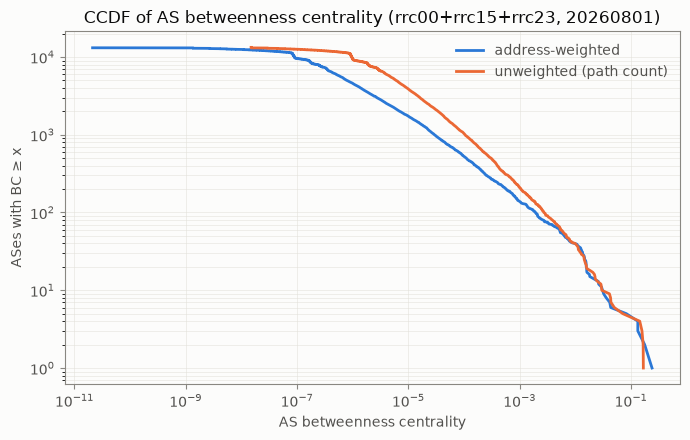

In [ ]:
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, SURFACE = "#e1e0d9", "#fcfcfb"
BLUE, ORANGE = "#2a78d6", "#eb6834"

def style_axes(ax):
    ax.set_facecolor(SURFACE)
    for spine in ax.spines.values():
        spine.set_color(MUTED)
        spine.set_linewidth(0.8)
    ax.tick_params(colors=MUTED, labelcolor=INK2)
    ax.grid(True, which="both", color=GRID, linewidth=0.6, alpha=0.6)
    ax.set_axisbelow(True)

def ccdf(values):
    xs = sorted(v for v in values if v > 0)  # edge ASes (BC = 0) cannot render on log axes
    return xs, [len(xs) - i for i in range(len(xs))]

fig, ax = plt.subplots(figsize=(7, 4.5))
fig.patch.set_facecolor(SURFACE)
style_axes(ax)

xw, yw = ccdf(df["bc_weighted"] / df["bc_weighted"].sum())
ax.plot(xw, yw, color=BLUE, linewidth=2, label="address-weighted")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("AS betweenness centrality", color=INK2)
ax.set_ylabel("ASes with BC ≥ x", color=INK2)
ax.set_title(f"CCDF of AS betweenness centrality ({LABEL}, {SNAPSHOT_DATE})",
             color=INK)
ax.legend(frameon=False, labelcolor=INK2)
fig.tight_layout()
plt.show()

## Task: AS Hegemony

In this task you will:

1. Compute $BC_{(j)}(v)$ for each viewpoint $j$ and AS $v$;
2. 
3. 

In [ ]:
ALPHA = 0.1                # fraction of viewpoints trimmed at each end (paper's value)
FULL_FEED_FRACTION = 0.75  # a viewpoint must carry >= this fraction of all announced IPv4 prefixes

vp_threshold = FULL_FEED_FRACTION * len(norm_weight)

# peer_counts (from pass 1) sums announcements across collectors, so a peer
# feeding two collectors is counted about twice here. That only overshoots,
# never undershoots: no genuine full feed is lost at this stage, and impostors
# are re-checked against their deduplicated route count after pass 3.
vp_meta = sorted(k for k, c in peer_counts.items() if c >= vp_threshold)
vp_index = {peer_ip: j for j, (peer_ip, _) in enumerate(vp_meta)}
num_vps = len(vp_meta)

print(f"{num_vps} candidate full-feed viewpoints "
      f"(>= {vp_threshold:,.0f} of {len(norm_weight):,} IPv4 prefixes) "
      f"in {len({asn for _, asn in vp_meta})} peer ASes, "
      f"out of {len(peer_counts)} peers total")

In [ ]:
# These three lines are included for efficiency reasons
gc.collect()
gc.freeze()
gc.disable()

t0 = time.time()
n_used = 0

addresses_per_vp = {}
zero_row = array("q", [0]) * num_vps
vp_total_w = array("q", zero_row)  # denominator per viewpoint: address mass

# Within one RIB dump each (peer, prefix) already appears exactly once; the
# dedup table is only needed when collectors are merged and a peer feeds several.
seen = SeenKeys(sum(c for (ip, _), c in peer_counts.items() if ip in vp_index))

for elem in iter_routes(RIB_PATHS, dedup=False, progress_every=0):
    j = vp_index.get(elem.peer_ip)

    # Filter out VPs that see few routes
    if j is None:
        continue
    # Filter out duplicate routes
    if not seen.add(hash((elem.peer_ip, elem.prefix))):
        continue

    w = weights.get(elem.prefix)

    # Filter out IPv6, default route, or unparseable prefix
    if w is None:
        continue
    path_str = elem.as_path
    # Filter out AS-set or missing path
    if path_str is None or "{" in path_str:
        continue

    n_used += 1
    if n_used % 5_000_000 == 0:
        print(f"  {n_used:,} viewpoint routes...")

    # Accumulate weight towards the denominator of BC_j(v)
    vp_total_w[j] += w

    for v in set(path_str.split()):  # a set collapses prepending on its own
        acc = addresses_per_vp.get(v)
        if acc is None:
            acc = addresses_per_vp[v] = array("q", zero_row)

        # Accumulate weight towards the numerator of BC_j(v)
        acc[j] += w

gc.enable()
gc.unfreeze()
print(f"{n_used:,} routes from {num_vps} candidate viewpoints, "
      f"{len(addresses_per_vp):,} ASes on-path ({time.time() - t0:.0f}s)")

In [ ]:
full = [j for j in range(num_vps) if vp_total_u[j] >= vp_threshold]
n_vp = len(full)
if n_vp == 0:
    raise RuntimeError("no full-feed viewpoints — lower FULL_FEED_FRACTION or add collectors")
k = int(ALPHA * n_vp)
print(f"{n_vp} of {num_vps} candidate viewpoints confirmed full-feed after dedup; "
      f"trimming {k} viewpoint(s) at each end (alpha={ALPHA})")
if n_vp < 20:
    print("WARNING: hegemony is unstable below ~20 viewpoints (paper, Fig. 1b)")

t0 = time.time()
totw = [vp_total_w[j] for j in full]

hege_rows = []
for asn_s, (aw, au) in addresses_per_vp.items():
    bc_w = sorted(aw[j] / tw for j, tw in zip(full, totw))
    hw = sum(bc_w[k:n_vp - k]) / (n_vp - 2 * k)
    if hw == 0:  # visible only through trimmed viewpoints
        continue
    asn = int(asn_s)
    name, country = asn_info.get(asn, ("", ""))
    hege_rows.append({
        "asn": asn,
        "name": name[:48],
        "country": country,
        "hegemony_w": hw,
        "hegemony_u": hu,
        "viewpoints": sum(1 for x in bc_u if x > 0),
    })

hege_df = (pd.DataFrame(hege_rows)
             .sort_values("hegemony_w", ascending=False)
             .reset_index(drop=True))
hege_df.insert(0, "rank_w", hege_df.index + 1)
print(f"{len(hege_df):,} ASes scored ({time.time() - t0:.0f}s)")

hege_df.head(25).style.format({
    "hegemony_w": "{:.4f}",
    "hegemony_u": "{:.4f}",
}).hide(axis="index")

In [ ]:
both = df.merge(hege_df, on="asn", suffixes=("_bc", "_hege"))
pos = both[(both["bc_weighted"] > 0) & (both["hegemony_w"] > 0)]

fig, ax = plt.subplots(figsize=(6.5, 6))
fig.patch.set_facecolor(SURFACE)
style_axes(ax)

lo = max(min(pos["bc_weighted"].min(), pos["hegemony_w"].min()), 1e-9)
hi = max(pos["bc_weighted"].max(), pos["hegemony_w"].max()) * 2
ax.plot([lo, hi], [lo, hi], color=MUTED, linewidth=1, linestyle="--", zorder=1)
ax.annotate("equal under both metrics", xy=(hi, hi),
            xytext=(-8, -14), textcoords="offset points",
            ha="right", fontsize=8, color=MUTED)

ax.scatter(pos["bc_weighted"], pos["hegemony_w"],
           s=14, color=BLUE, alpha=0.45, linewidths=0, zorder=2)

for _, row in pos.nlargest(8, "hegemony_w").iterrows():
    ax.annotate(f"AS{row['asn']}", xy=(row["bc_weighted"], row["hegemony_w"]),
                xytext=(5, 3), textcoords="offset points",
                fontsize=8, color=INK2)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_xlabel("Pooled betweenness centrality (address-weighted)", color=INK2)
ax.set_ylabel("AS hegemony (address-weighted)", color=INK2)
ax.set_title(f"AS hegemony vs. pooled BC ({LABEL}, {SNAPSHOT_DATE})", color=INK)
fig.tight_layout()
plt.show()